In [6]:
# %pip install -r requirements.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import kmrf as kmrf

%matplotlib inline

In [7]:
# # Load and retrain each saved model with adjusted train/val/test dates and set raw data, and save the updated model
# for classification_dir in ['adapted', 'original']:

#     for asset_class_dir in ['us_equity', 'commodity']:
#         saved_models_dir = Path(f'saved_models/KMRF/{classification_dir}_labels/{asset_class_dir}')
#         saved_models_list = sorted(list(saved_models_dir.glob('*.pkl')))

#         for i in range(len(saved_models_list)):
#             print(f"\nLoading and retraining model index = {i}: {saved_models_list[i].name}\n")
#             kmrf_model = kmrf.KMRF.load_model(saved_models_list[i])
#             kmrf_model.set_raw_data()
#             kmrf_model.adjust_train_val_test_dates(val_start='2019-04-01', val_end='2021-09-30',
#                                         test_start='2021-11-01', test_end='2025-10-24')
#             kmrf_model.fit()
#             kmrf_model.save_model(boruta_used=True)

In [8]:
classification_dir = 'adapted'  # Specify the classification directory here
asset_class_dir = 'us_equity'    # Specify the asset class directory here

In [9]:
# List available saved KMRF models for specified classification and asset class
saved_models_dir = Path(f'saved_models/KMRF/{classification_dir}_labels/{asset_class_dir}')

if saved_models_dir.exists():
    saved_models_list = list(saved_models_dir.glob('*.pkl'))

    if saved_models_list:
        saved_models_list = sorted(saved_models_list)
        print(f"Available saved models in '{saved_models_dir}':\n")
        for i, model_path in enumerate(saved_models_list):
            print(f" index = {i}: {model_path.name}")
    else:
        print(f"No saved models found in '{saved_models_dir}'. Train a model first!")

Available saved models in 'saved_models/KMRF/adapted_labels/us_equity':

 index = 0: KMRF_Consumer-Discretionary-Select-Sector-SPDR_20190101_boruta.pkl
 index = 1: KMRF_Consumer-Staples-Select-Sector-SPDR_20190101_boruta.pkl
 index = 2: KMRF_Energy-Select-Sector-SPDR_20190101_boruta.pkl
 index = 3: KMRF_Financial-Select-Sector-SPDR_20190101_boruta.pkl
 index = 4: KMRF_Health-Care-Select-Sector-SPDR_20190101_boruta.pkl
 index = 5: KMRF_Industrial-Select-Sector-SPDR_20190101_boruta.pkl
 index = 6: KMRF_Invesco-QQQ-Trust_20190101_boruta.pkl
 index = 7: KMRF_Materials-Select-Sector-SPDR_20190101_boruta.pkl
 index = 8: KMRF_SPDR-S&P-500-ETF_20190101_boruta.pkl
 index = 9: KMRF_Technology-Select-Sector-SPDR_20190101_boruta.pkl
 index = 10: KMRF_Utilities-Select-Sector-SPDR_20190101_boruta.pkl
 index = 11: KMRF_iShares-Micro-Cap-ETF_20190101_boruta.pkl
 index = 12: KMRF_iShares-Russell-2000-ETF_20190101_boruta.pkl
 index = 13: KMRF_iShares-Russell-2000-Growth-ETF_20190101_boruta.pkl
 index = 

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: adapted
  End date: 20190101
  Using pre-computed features: True
  Data path: data/ready/us_equity.csv
  KAMA+MSR model directory: saved_models/KAMA_MSR/us_equity/20190101
  Validation period: 2019-04-01 00:00:00 to 2021-09-30 00:00:00
  Test start: 2021-11-01 00:00:00
  Random seed: 1010


KMRF('us_equity, SPDR S&P 500 ETF')
Raw Price Data (8242, 4): 1993-01-29 to 2025-10-24
Train (6041, 107): 1995-01-04 to 2018-12-31
Val (568, 107): 2019-04-01 to 2021-09-30
Test (1001, 107): 2021-11-01 to 2025-10-24


Generating predictions...
  Input shape: (568, 107)
  Using pre-selected features: 107
✓ Generated probability predictions: (568, 3)


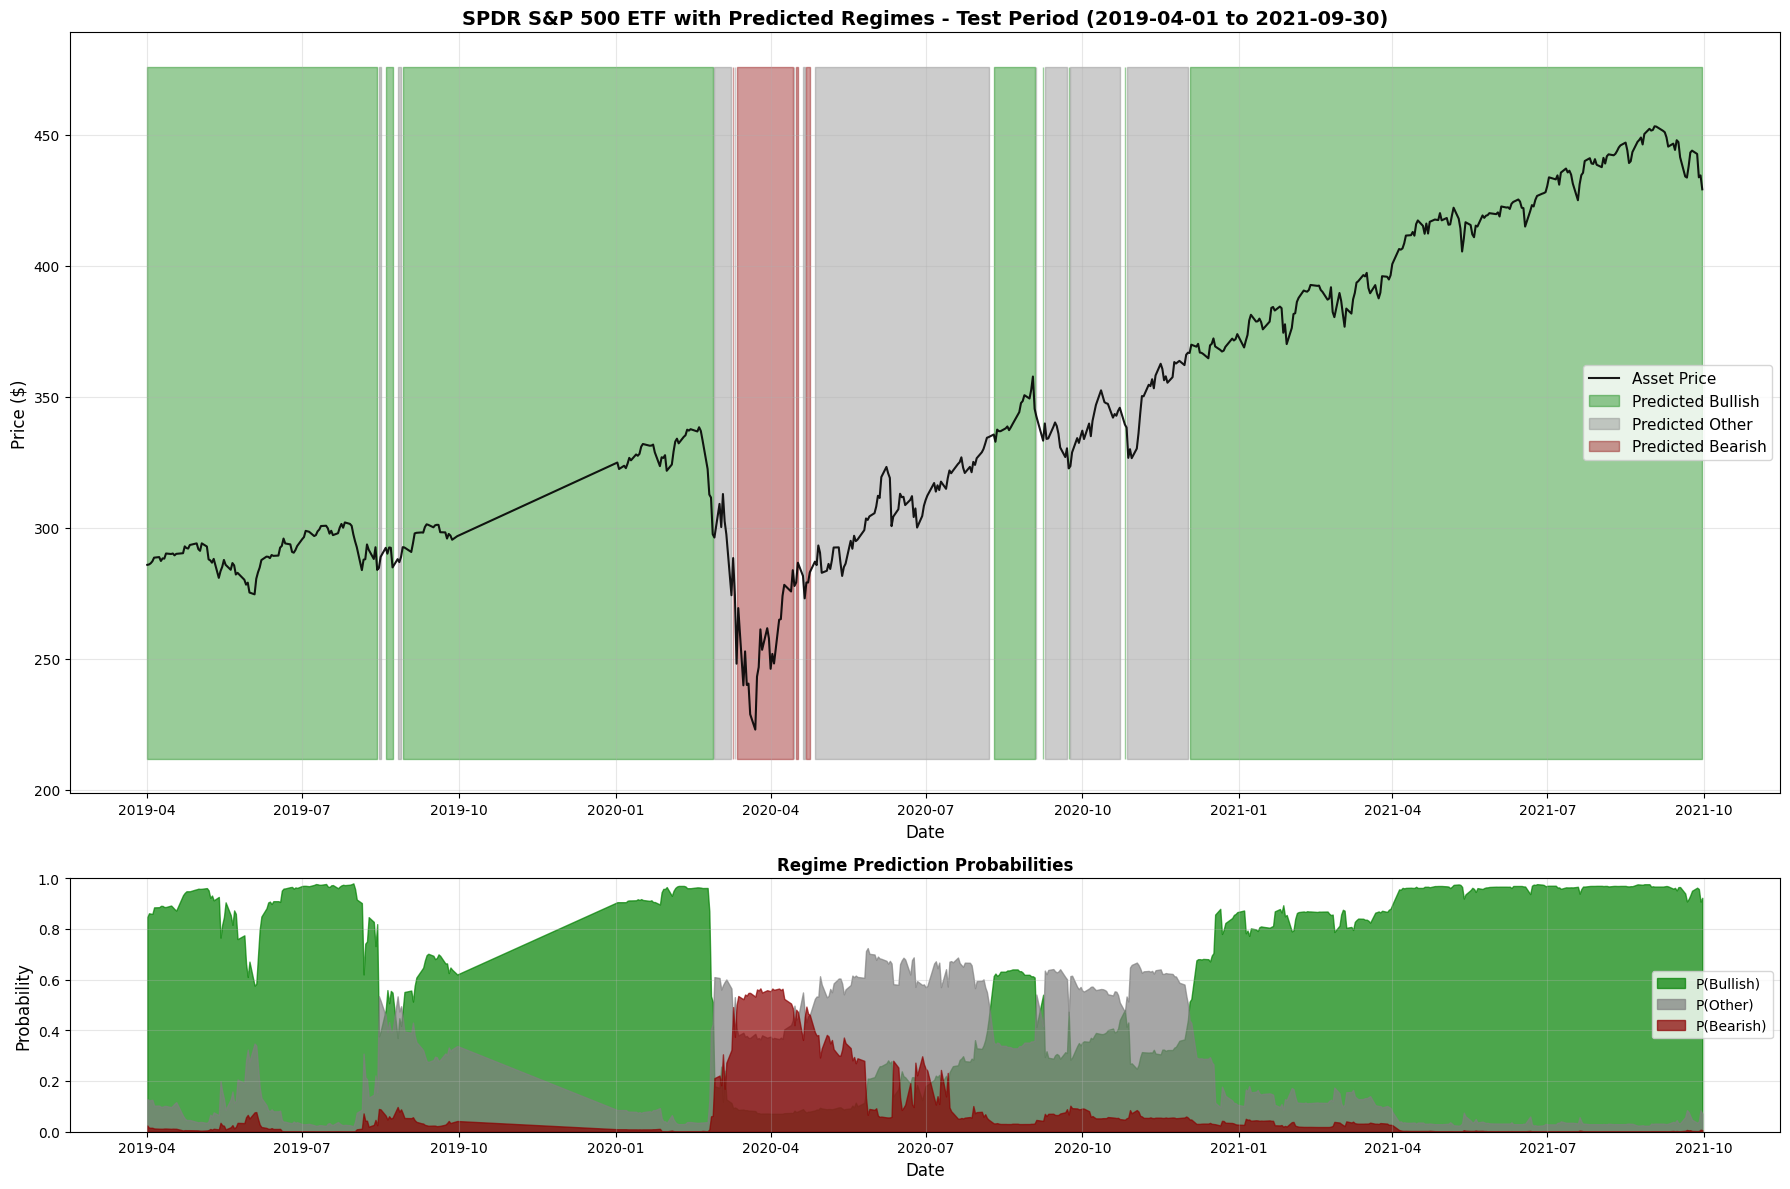


✓ Regime visualization complete!

PREDICTION SUMMARY FOR SPDR S&P 500 ETF
Test Period: 2019-04-01 to 2021-09-30
Total Trading Days: 568

Price Performance:
  Start Price (open on 2019-04-01): $284.70
  End Price (close on 2021-09-30): $429.14
  Buy and Hold Return: 50.73%

Regime Prediction Statistics:
   Bearish:  29 days (  5.1%) | Avg Prob: 0.075
     Other: 148 days ( 26.1%) | Avg Prob: 0.258
   Bullish: 391 days ( 68.8%) | Avg Prob: 0.667

High Confidence Predictions (>70%): 327 days (57.6%)


In [10]:
kmrf_model = kmrf.KMRF.load_model(saved_models_list[8])
display(kmrf_model)
kmrf_model.predict(test_or_val='val')
kmrf_model.viz_predictions(test_or_val='val')